# 13.4.2 分解不确定性与排序反转

## 学习目标与先修知识

在共同观测（observation）量下分项比较参数（parameter）、观测和结构差异。

先修：13.4.1 粗观测信息损失；6.5 独立验证；9.5 预测检查。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

预测不稳可能来自参数、观测处理或结构规则。把所有差异合成一个数字后，我们还能说清在哪些条件下某个干预更好吗？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

给定同一无量纲（dimensionless）指标参考值0.50，只改参数得0.60、只改观测得0.45、只改结构得0.72。先分别计算有符号差。

In [2]:
reference=.50
print('单因素差：',[value-reference for value in [.60,.45,.72]])

单因素差： [0.09999999999999998, -0.04999999999999999, 0.21999999999999997]


## 模型假设

共同指标、单位、评价时刻和场景固定。三个结果均只改变一个因素，以同一参考为基线；它们是局部对照而非独立随机误差方差（variance）。两种干预的粗、细尺度评分均定义为越大越好。若多个因素同时改变，需额外检验交互。

## 数学解释与推导

定义 $\Delta_\theta=Y(\theta_1,o_0,M_0)-Y(\theta_0,o_0,M_0)$，观测与结构对照 $\Delta_o,\Delta_M$ 类似。三者使用相同参考 $Y_0$，但一般 $Y(\theta_1,o_1,M_1)-Y_0\ne\Delta_\theta+\Delta_o+\Delta_M$，因为可能有交互。比较干预 A、B 时，令 $d_s=Y_{A,s}-Y_{B,s}$；若两个尺度的 $d_s$ 符号相反，称本题的排序反转（ranking reversal）。它只约束给定尺度和指标，不确定哪种干预在所有条件下更好。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def contrast_components(reference, parameter_only, observation_only, structure_only):
    """One-factor contrasts from a common reference, not variance components."""
    return [parameter_only - reference, observation_only - reference,
            structure_only - reference]


def scale_ranking(coarse_a, coarse_b, fine_a, fine_b):
    """Higher score is preferred; 0 is a tie, 1 favors A, -1 favors B."""
    def winner(a, b):
        return (a > b) - (a < b)
    coarse, fine = winner(coarse_a, coarse_b), winner(fine_a, fine_b)
    return [coarse, fine, coarse * fine == -1]

## 对照实验

先列出三项单因素差，再比较 A/B 在粗与细尺度的排序；扫描一组参数范围并公开最大差。

C:\Users\10149\AppData\Local\Temp\ipykernel_35048\1922866410.py:10: UserWarning: The figure layout has changed to tight
  axes[1].legend();plt.tight_layout();plt.show()


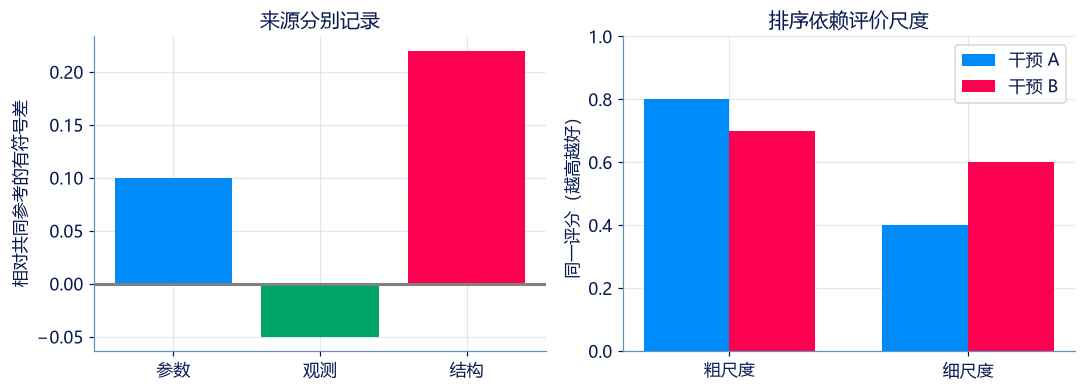

三项单因素差 [0.09999999999999998, -0.04999999999999999, 0.21999999999999997] ；粗/细胜者及反转 [1, -1, True]


In [4]:
difference=contrast_components(.5,.6,.45,.72)
ranking=scale_ranking(.8,.7,.4,.6)
fig,axes=plt.subplots(1,2,figsize=(10,3.7))
axes[0].bar(['参数','观测','结构'],difference,color=[BLUE,GREEN,PINK]);axes[0].axhline(0,color='gray')
axes[0].set(ylabel='相对共同参考的有符号差',title='来源分别记录')
x=np.arange(2)
axes[1].bar(x-.18,[.8,.4],width=.36,label='干预 A',color=BLUE)
axes[1].bar(x+.18,[.7,.6],width=.36,label='干预 B',color=PINK)
axes[1].set(xticks=x,xticklabels=['粗尺度','细尺度'],ylim=(0,1),ylabel='同一评分（越高越好）',title='排序依赖评价尺度')
axes[1].legend();plt.tight_layout();plt.show()
print('三项单因素差',difference,'；粗/细胜者及反转',ranking)

## 结果解释

参数、观测和结构改变的有符号差分别记录，避免把结构失配叫成噪声。例中粗尺度 A 优、细尺度 B 优；若决策目标尚未固定，应报告这种反转，而非只挑有利尺度。

### 独立核对

手算有符号差、相同得分的平局及符号反转；说明不能把单因素差默认为组合差。

In [5]:
np.testing.assert_allclose(difference,[.1,-.05,.22])
assert ranking==[1,-1,True]
assert scale_ranking(.5,.5,.4,.6)==[0,-1,False]
print('共同参考、平局与排序反转核对通过。')

共同参考、平局与排序反转核对通过。


## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：分项计算三种差异

给定同一评价指标的共同参考结果及只改变参数（parameter）、只改变观测（observation）处理、只改变模型结构（model structure）的三个结果。返回各自相对参考的有符号差，不把它们误称为独立方差（variance）贡献。

**函数与代码模板**

```python
def solve(
    reference: float,
    parameter_only: float,
    observation_only: float,
    structure_only: float,
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `reference` | `float` | 共同参考结果。 | 指标单位 |
| `parameter_only` | `float` | 仅改变参数得到的结果。 | 指标单位 |
| `observation_only` | `float` | 仅改变观测方式得到的结果。 | 指标单位 |
| `structure_only` | `float` | 仅改变模型结构得到的结果。 | 指标单位 |

**返回值**

直接返回 differences（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `differences` | `list[float]` | 参数、观测、结构相对参考的有符号差。 | 指标单位 |

**计算规则**

三组差异都以同一 reference 为基线；交互效应未包含，不能把差异直接相加预测组合条件。

**约束与边界**

- 所有比较使用题定模型（model）和相同单位；仅输出（output）函数返回值，不依赖外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| reference | 共同参考结果。 | 1 | 指标单位 |
| parameter_only | 仅改变参数得到的结果。 | 1.2 | 指标单位 |
| observation_only | 仅改变观测方式得到的结果。 | 0.8 | 指标单位 |
| structure_only | 仅改变模型结构得到的结果。 | 1.5 | 指标单位 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
reference = 1.0
parameter_only = 1.2
observation_only = 0.8
structure_only = 1.5

result = solve(reference, parameter_only, observation_only, structure_only)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| differences | 参数、观测、结构相对参考的有符号差。 | [0.19999999999999996, -0.19999999999999996, 0.5] | 指标单位 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.19999999999999996,
                   -0.19999999999999996,
                   0.5]
```

**样例解释**

保持单位和共同参考一致；有符号差说明方向，不等于统计方差分解。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：分项计算三种差异](http://127.0.0.1:8000/chapters/13-04-%E5%A4%9A%E5%B0%BA%E5%BA%A6%E3%80%81%E7%B2%97%E7%B2%92%E5%8C%96%E4%B8%8E%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7/practice/?question=p13-one-factor-contrasts)

### 第 2 题 · 单项选择题：不要混合不确定性来源

参数（parameter）范围变化、观测（observation）降采样（sampling）和替代网络结构都改变最终预测。哪项报告最有信息？

- **A.** 分别列出各单因素对照、共同指标和范围，再说明可能存在交互。
- **B.** 把三者简单加总并叫作唯一随机误差。
- **C.** 只报告最大的一条轨迹（trajectory）。
- **D.** 把观测差异解释为参数因果效应。

[作答：不要混合不确定性来源](http://127.0.0.1:8000/chapters/13-04-%E5%A4%9A%E5%B0%BA%E5%BA%A6%E3%80%81%E7%B2%97%E7%B2%92%E5%8C%96%E4%B8%8E%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7/practice/?question=p13-uncertainty-sources)

### 第 3 题 · 单项选择题：尺度变化时排序可能反转

两个干预 A、B 在粗尺度得分为0.8、0.7，在细尺度得分为0.4、0.6（均为越高越好）。哪项正确？

- **A.** 粗尺度 A 优，细尺度 B 优，存在排序反转（ranking reversal）。
- **B.** 两个尺度都 A 优。
- **C.** 排序反转证明 A 在所有条件下无效。
- **D.** 只要粗尺度 A 优就可忽略细尺度。

[作答：尺度变化时排序可能反转](http://127.0.0.1:8000/chapters/13-04-%E5%A4%9A%E5%B0%BA%E5%BA%A6%E3%80%81%E7%B2%97%E7%B2%92%E5%8C%96%E4%B8%8E%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7/practice/?question=p13-ranking-reversal)

### 第 4 题 · 单项选择题：敏感性有声明范围

在参数（parameter） theta∈[0.9,1.1] 内，输出（output）变化至多0.03。能推出哪项？

- **A.** 这只证明指定模型（model）、指标和范围内的数值稳定。
- **B.** 所有 theta 和所有模型都稳定。
- **C.** 观测（observation）误差自动为零。
- **D.** 干预在现实中必有效。

[作答：敏感性有声明范围](http://127.0.0.1:8000/chapters/13-04-%E5%A4%9A%E5%B0%BA%E5%BA%A6%E3%80%81%E7%B2%97%E7%B2%92%E5%8C%96%E4%B8%8E%E4%B8%8D%E7%A1%AE%E5%AE%9A%E6%80%A7/practice/?question=p13-sensitivity-range)

**进一步阅读**

[Network Science 在线教材](https://networksciencebook.com/translations/en/partials/chapter.html)与[SFI Complexity Explorer](https://www.complexityexplorer.org/courses/185-introduction-to-complexity/faq)分别提供结构和尺度背景；不确定性分项由本节公开实验定义。